In [275]:
import numpy as np 
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

# Extraction using spectral features

https://se.mathworks.com/help/audio/ref/audiofeatureextractor.html, see SpectralEntropy etc.

https://se.mathworks.com/help/audio/ug/voice-activity-detection-in-noise-using-deep-learning.html, see afe. 

In [276]:
def _safe_div(a, b, eps=1e-10):
    return a / (b + eps)

def _spectral_entropy(P, eps=1e-10):
    """Normalized spectral entropy per frame on power spectrum P (freq x frames)."""
    P_sum = np.sum(P, axis=0, keepdims=True) + eps
    p = P / P_sum
    H = -np.sum(p * np.log(p + eps), axis=0)
    H_norm = H / np.log(P.shape[0])  # normalize to [0,1]
    return H_norm

def _spectral_crest(P, eps=1e-10):
    """Spectral crest factor per frame."""
    return _safe_div(P.max(axis=0), P.mean(axis=0), eps=eps)

def _spectral_flatness(P, eps=1e-10):
    """Spectral flatness per frame."""
    log_P = np.log(P + eps)
    geo_mean = np.exp(np.mean(log_P, axis=0))
    arith_mean = P.mean(axis=0)
    return _safe_div(geo_mean, arith_mean, eps=eps)

def _spectral_flux(S, eps=1e-10):
    """Positive spectral flux per frame on magnitude spectrogram S (freq x frames)."""
    # Difference along time axis
    dS = np.diff(S, axis=1)
    # Only positive changes
    dS_pos = np.maximum(dS, 0.0)
    flux = np.sqrt(np.sum(dS_pos**2, axis=0))
    # Pad first frame with 0 to keep same length as other features
    return np.concatenate(([0.0], flux))

def _spectral_rolloff(P, freqs, roll_percent=0.95):
    """Spectral rolloff frequency per frame."""
    cumsum = np.cumsum(P, axis=0)
    total = cumsum[-1, :]
    thresh = roll_percent * total
    # For each frame, find first bin where cumsum >= thresh
    idx = np.argmax(cumsum >= thresh[None, :], axis=0)
    return freqs[idx]

def _spectral_moments(P, freqs, eps=1e-10):
    """
    Weighted spectral moments -> mean, variance, skewness, kurtosis per frame.
    P: power (freq x frames), freqs: (freq,)
    """
    P_sum = np.sum(P, axis=0, keepdims=True) + eps
    p = P / P_sum  # normalized weights

    # first moment (mean)
    mu = np.sum(freqs[:, None] * p, axis=0)

    # central moments
    diff = freqs[:, None] - mu[None, :]
    var = np.sum((diff**2) * p, axis=0)
    std = np.sqrt(var + eps)

    skew = np.sum((diff**3) * p, axis=0) / (std**3 + eps)
    kurt = np.sum((diff**4) * p, axis=0) / (std**4 + eps)

    return mu, var, skew, kurt

def _spectral_slope(S, freqs, eps=1e-10):
    """
    Spectral slope via linear regression of magnitude vs frequency per frame.
    S: magnitude (freq x frames), freqs: (freq,)
    """
    f = freqs[:, None]
    f_mean = np.mean(f)
    S_mean = np.mean(S, axis=0, keepdims=True)

    num = np.sum((f - f_mean) * (S - S_mean), axis=0)
    den = np.sum((f - f_mean)**2, axis=0) + eps
    slope = num / den
    return slope

def extract_audio_features(
    y,
    sr,
    n_fft=1024,
    hop_length=512,
    win_length=1024,
    roll_percent=0.95,
):
    """
    Extract a set of spectral features similar to MATLAB's audioFeatureExtractor.

    Returns:
    feat_matrix : np.ndarray, shape (n_frames, n_features)
        Columns in order:
        [centroid, crest, entropy, flatness, flux,
         kurtosis, skewness, rolloff, slope]
    feat_dict : dict of np.ndarray
        Keys: 'centroid', 'crest', 'entropy', 'flatness', 'flux',
              'kurtosis', 'skewness', 'rolloff', 'slope'
        Each value is shape (n_frames,)
    """

    # STFT.
    S_complex = librosa.stft(
        y,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        window="hann",
        center=True,
    )
    S = np.abs(S_complex) # Magnitude.
    P = S**2 # Power.
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)  # (freq,)

    # Features.
    # Spectral centroid (librosa implementation).
    centroid = librosa.feature.spectral_centroid(
        S=P,
        sr=sr
    ).squeeze(0) # (frames,)

    crest = _spectral_crest(P)
    entropy = _spectral_entropy(P)
    flatness = _spectral_flatness(P)
    flux = _spectral_flux(S)
    mu, var, skewness, kurtosis = _spectral_moments(P, freqs)
    rolloff = _spectral_rolloff(P, freqs, roll_percent=roll_percent)
    slope = _spectral_slope(S, freqs)

    # Stack into (frames, features)
    feat_matrix = np.vstack([
        centroid,
        crest,
        entropy,
        flatness,
        flux,
        kurtosis,
        skewness,
        rolloff,
        slope,
    ]).T

    feat_dict = {
        "centroid": centroid,
        "crest": crest,
        "entropy": entropy,
        "flatness": flatness,
        "flux": flux,
        "kurtosis": kurtosis,
        "skewness": skewness,
        "rolloff": rolloff,
        "slope": slope,
    }

    return feat_matrix, feat_dict

#### Example

In [277]:
val1_sample = r"D:\data_dryad\Tracy_6230\6230.220917120000.wav"
val2_sample = r"D:\data_dryad\Tracy_6230\6230.221003000000.wav"
y, sr = sf.read(val1_sample)

feat_matrix, feat_dict = extract_audio_features(y, sr)

In [278]:
print(feat_matrix.shape)
print({k: v.shape for k, v in feat_dict.items()})

(33743, 9)
{'centroid': (33743,), 'crest': (33743,), 'entropy': (33743,), 'flatness': (33743,), 'flux': (33743,), 'kurtosis': (33743,), 'skewness': (33743,), 'rolloff': (33743,), 'slope': (33743,)}


In [687]:
def detect_tonal_frames(feat_dict, centroid_th=500, crest_th=65
    , entropy_th=0.9, flatness_th=0.5, flux_th=0.6
    , kurtosis_th=1, skewness_th=(8, -2)
    , rolloff_th=2000, slope_th=-5.0):

    cent = feat_dict["centroid"]
    crest = feat_dict["crest"]
    ent = feat_dict["entropy"]
    flat = feat_dict["flatness"]
    flux = feat_dict["flux"]
    kurtosis = feat_dict["kurtosis"]
    skewness_high = feat_dict["skewness"][0]
    skewness_low = feat_dict["skewness"][1]
    rolloff = feat_dict["rolloff"]
    slope = feat_dict["slope"]

    tonal_mask = ((cent > centroid_th) & (crest > crest_th) & (ent < entropy_th) 
                  & (flat < flatness_th) & (flux < flux_th) 
                  & (kurtosis > kurtosis_th) 
                  & ((skewness_high < skewness_th[0]) | (skewness_low > skewness_th[1]))
                  & (rolloff > rolloff_th) & (slope > slope_th))
    
    return tonal_mask

In [688]:
def frames_to_events(mask, hop_length, sr, min_duration=0.1):
    """
    Convert a boolean frame mask to time intervals.
    Returns list of (t_start, t_end) in seconds.
    """
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0:
        return []

    events = []
    in_event = False
    start_idx = 0

    for i, v in enumerate(mask):
        if v and not in_event:
            in_event = True
            start_idx = i
        elif not v and in_event:
            in_event = False
            end_idx = i
            # Compute times.
            t_start = start_idx * hop_length / sr
            t_end = end_idx * hop_length / sr
            if (t_end - t_start) >= min_duration:
                events.append((t_start, t_end))

    # Handle any trailing event.
    if in_event:
        end_idx = len(mask)
        t_start = start_idx * hop_length / sr
        t_end   = end_idx * hop_length / sr
        if (t_end - t_start) >= min_duration:
            events.append((t_start, t_end))

    return events

In [689]:
def frequency_stable_mask(centroid, win=3, max_std_hz=200.0):
    c = np.asarray(centroid)
    N = len(c)
    stable = np.zeros(N, dtype=bool)
    for n in range(N):
        lo = max(0, n - win)
        hi = min(N, n + win + 1)
        seg = c[lo:hi]
        if seg.size > 1 and np.std(seg) <= max_std_hz:
            stable[n] = True
    return stable

In [690]:
y1, sr1 = sf.read(val1_sample)
feats1, dict1 = extract_audio_features(y1, sr1)
y2, sr2 = sf.read(val2_sample)
feats2, dict2 = extract_audio_features(y2, sr2)

tonal_mask1 = detect_tonal_frames(dict1)
events1 = frames_to_events(tonal_mask1, hop_length=512, sr=sr1, min_duration=0.1)

tonal_mask2 = detect_tonal_frames(dict2)
events2 = frames_to_events(tonal_mask2, hop_length=512, sr=sr2, min_duration=0.1)

In [691]:
for t0, t1 in events1:
    print(f"Tonal segment from {t0:.2f} to {t1:.2f} s")

Tonal segment from 9.80 to 10.02 s
Tonal segment from 21.58 to 21.70 s
Tonal segment from 28.68 to 28.82 s
Tonal segment from 29.30 to 29.68 s
Tonal segment from 29.69 to 29.81 s
Tonal segment from 29.82 to 31.66 s
Tonal segment from 31.68 to 31.87 s
Tonal segment from 54.64 to 54.76 s
Tonal segment from 69.09 to 69.25 s
Tonal segment from 69.57 to 69.70 s
Tonal segment from 70.05 to 70.51 s
Tonal segment from 70.93 to 71.14 s
Tonal segment from 71.15 to 71.34 s
Tonal segment from 71.34 to 72.39 s
Tonal segment from 73.13 to 73.49 s
Tonal segment from 73.50 to 73.68 s
Tonal segment from 73.69 to 73.87 s
Tonal segment from 73.88 to 74.25 s
Tonal segment from 75.07 to 75.54 s
Tonal segment from 78.14 to 78.41 s
Tonal segment from 78.42 to 78.58 s
Tonal segment from 78.58 to 78.74 s
Tonal segment from 78.75 to 78.94 s
Tonal segment from 88.08 to 88.22 s
Tonal segment from 88.22 to 88.33 s
Tonal segment from 94.75 to 94.87 s
Tonal segment from 97.14 to 97.36 s
Tonal segment from 97.50 to 9

In [692]:
for t0, t1 in events2:
    print(f"Tonal segment from {t0:.2f} to {t1:.2f} s")

Tonal segment from 49.82 to 50.20 s
Tonal segment from 51.61 to 51.86 s
Tonal segment from 57.53 to 57.80 s
Tonal segment from 57.87 to 58.22 s
Tonal segment from 65.29 to 65.42 s
Tonal segment from 108.73 to 110.45 s
Tonal segment from 110.65 to 110.94 s
Tonal segment from 110.95 to 111.06 s
Tonal segment from 129.49 to 129.65 s
Tonal segment from 130.41 to 130.94 s
Tonal segment from 131.50 to 131.78 s
Tonal segment from 147.13 to 147.23 s
Tonal segment from 147.49 to 147.94 s
Tonal segment from 147.95 to 149.50 s
Tonal segment from 176.79 to 177.40 s
Tonal segment from 178.36 to 178.98 s
Tonal segment from 197.61 to 197.76 s
Tonal segment from 213.38 to 213.59 s
Tonal segment from 217.14 to 217.25 s
Tonal segment from 217.30 to 217.50 s
Tonal segment from 217.51 to 217.74 s
Tonal segment from 219.48 to 219.88 s
Tonal segment from 239.09 to 239.66 s
Tonal segment from 240.57 to 240.92 s


In [693]:
fps = sr1 / 512
i_start, i_end = int(20.4*fps), int(22.4*fps)
print(i_start+(fps*5), i_end+(fps*5), "\n")
test_seg = y1[i_start:i_end]
for key, val in extract_audio_features(test_seg, sr1)[1].items():
    print(f"{key}: {val.mean():.2f}")

3175.0 3425.0 

centroid: 149.83
crest: 197.43
entropy: 0.26
flatness: 0.00
flux: 0.00
kurtosis: 543.67
skewness: 20.85
rolloff: 375.00
slope: -0.00


In [694]:
fps = sr2 / 512
i_start, i_end = int(251*fps), int(252*fps)
print(fps, i_start, i_end, "\n")
test_seg = y2[i_start:i_end]
for key, val in extract_audio_features(test_seg, sr2)[1].items():
    print(f"{key}: {val.mean():.2f}")
# Good examples: 251-253 sec, 

125.0 31375 31500 

centroid: 323.02
crest: 111.40
entropy: 0.36
flatness: 0.01
flux: 0.00
kurtosis: 227.04
skewness: 13.48
rolloff: 875.00
slope: -0.00


In [695]:
feat_dict.keys()
for k in feat_dict.keys():
    mean_val = feat_dict[k].mean()
    print(f"{k} mean = {mean_val:.4f}")

centroid mean = 1933.6829
crest mean = 290.7519
entropy mean = 0.3215
flatness mean = 0.0267
flux mean = 0.1868
kurtosis mean = 271.2771
skewness mean = 7.5349
rolloff mean = 6668.9184
slope mean = -0.0000


In [696]:
tonal_mask = detect_tonal_frames(feat_dict, 
    entropy_th=10, 
    flatness_th=1,
    crest_th=90, 
    kurtosis_th=25, 
    skewness_th=(7, -5),
    flux_th=10, 
    slope_th=-5, 
    rolloff_th=3000)
events = frames_to_events(tonal_mask, hop_length=512, sr=sr)
for t0, t1 in events:
    print(f"Tonal segment from {t0:.2f} to {t1:.2f} s")

Tonal segment from 30.51 to 30.62 s
Tonal segment from 30.66 to 30.78 s
Tonal segment from 31.48 to 31.62 s
Tonal segment from 78.76 to 78.88 s
Tonal segment from 100.70 to 100.83 s
Tonal segment from 127.32 to 127.75 s
Tonal segment from 129.37 to 129.47 s
Tonal segment from 135.19 to 135.30 s
Tonal segment from 167.72 to 167.86 s


32500 33125
start sec: 260.0
end sec: 265.0


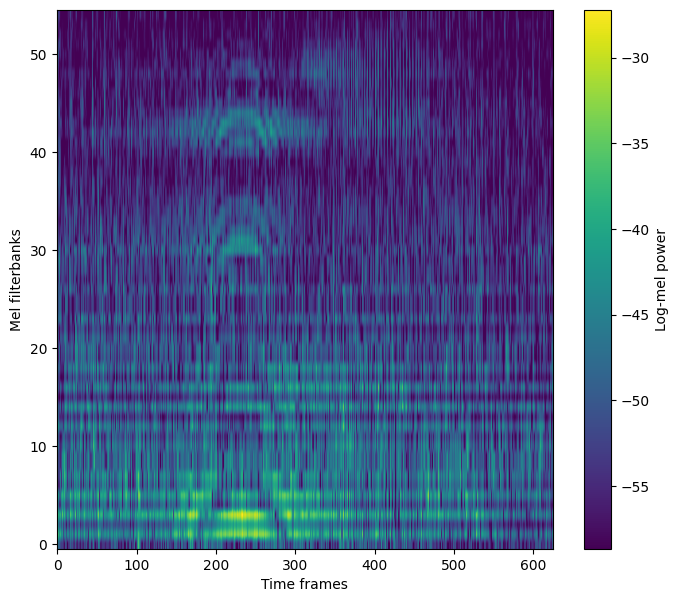

In [697]:
y, sr = librosa.load(val1_sample, sr=sr)

spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=512,
    n_mels=128, fmin=0, fmax=sr//2,)
spec_db = librosa.power_to_db(spec, ref=1)

t_start = 260
t_end = 265
hop_length = 512
fps = sr / hop_length
i_start = int(t_start * fps)
i_end   = int(t_end   * fps)
print(i_start, i_end)
print("start sec:", i_start * hop_length / sr)
print("end sec:", i_end * hop_length / sr)

mels_start = 9
mels_end = 64

seg1 = spec_db[mels_start:mels_end, i_start:i_end]
n_frames_seg = seg1.shape[1]
t_seg = np.arange(i_start, i_start + n_frames_seg) * hop_length / sr

fig, ax = plt.subplots(figsize=(8, 7))
img = ax.imshow(seg1, aspect='auto', origin='lower', extent=[t_seg[0], t_seg[-1], mels_start, mels_end])
ax.imshow(seg1, aspect='auto', origin='lower')
cbar = fig.colorbar(ax.images[0], ax=ax)
cbar.set_label('Log-mel power')
ax.set_xlabel('Time frames')
ax.set_ylabel('Mel filterbanks')
plt.show()

28687.5 28692.5 229.5 229.54


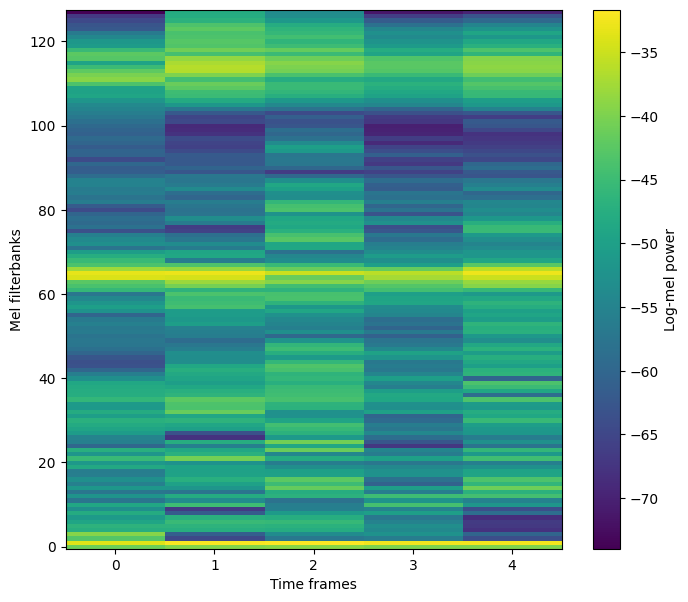

In [698]:
t_start = 224.5 + 5
t_end = t_start + 0.04
seg1_wave = librosa.load(val1_sample, sr=sr, offset=t_start, duration=(t_end - t_start))[0]
print(t_start*fps, t_end*fps, t_start, t_end, )
fm1, fd1 = extract_audio_features(seg1_wave, sr)
seg1_spec = librosa.feature.melspectrogram(y=seg1_wave, sr=sr, n_fft=1024, hop_length=512,
    n_mels=128, fmin=0, fmax=sr//2,)
seg1_db = librosa.power_to_db(seg1_spec, ref=1)

fig, ax = plt.subplots(figsize=(8, 7))
img = ax.imshow(seg1_db, aspect='auto', origin='lower')
ax.imshow(seg1_db, aspect='auto', origin='lower')
cbar = fig.colorbar(ax.images[0], ax=ax)
cbar.set_label('Log-mel power')
ax.set_xlabel('Time frames')
ax.set_ylabel('Mel filterbanks')
plt.show()

In [699]:
y3, sr3 = sf.read(val1_sample)
y3 = y3[int(t_start*sr3):int(t_end*sr3)]
feats3, dict3 = extract_audio_features(y3, sr3)
tonal_mask3 = detect_tonal_frames(dict3)
events3 = frames_to_events(tonal_mask3, hop_length=512, sr=sr3, min_duration=0.1)

for t0, t1 in events3:
    print(f"Tonal segment from {t0:.2f} to {t1:.2f} s")

In [700]:
for key, val in dict3.items():
    print(f"{key}: {val.mean():.3f}")

centroid: 14158.298
crest: 49.298
entropy: 0.785
flatness: 0.156
flux: 0.331
kurtosis: 1.833
skewness: -0.528
rolloff: 24552.083
slope: 0.000


In [712]:
# Read a npz file.
file_path = r"E:\beats_extraction_sample\6229.220802122000.npz"
# Check keys.
with np.load(file_path) as z:
    print("Keys in npz file:", z.files)
    print("Feature shape:", z["feature"].shape)
    s = z["feature"]
    print(s.shape)
    print(s.ndim)
    s = s[0]
    print(s.shape)
    s = np.squeeze(z["feature"])
    print("Squeezed shape:", s.shape)

Keys in npz file: ['feature', 'sr', 'source_path']
Feature shape: (1, 13240, 768)
(1, 13240, 768)
3
(13240, 768)
Squeezed shape: (13240, 768)


In [713]:
4.5*60 - 5

265.0